# 03 — Modelo técnico

## O que estamos tentando calcular

1. Quanto etanol **puro** obtivemos por litro de soro, em cada cenário de teor alcoólico?
2. Como isso se compara ao **rendimento teórico** (estequiometria) e à **eficiência industrial reportada na literatura**?
3. Quanto etanol seria produzido a partir de 100 L, 1.000 L, 10.000 L, 100.000 L e 1.000.000 L de soro?
4. Quais são as principais perdas do processo?

## Dados necessários (e de onde vêm)

| Dado | Origem | Notebook |
|---|---|---|
| Recuperação na filtração (64%), razão destilado/mosto (9,4%) | Medido | 01 |
| Teor alcoólico do destilado (5% / 8,5% / 12%) | Premissa de projeto (faixa esperada do relatório) | 01 |
| Concentração de lactose no soro (~49 g/L) | Externo (proxy de literatura) | 02 |
| Rendimento teórico estequiométrico (0,538 g/g) | Calculado (estequiometria) | 02 |
| Eficiência industrial de fermentação (80–97%) | Externo (literatura, rota biológica diferente) | 02 |

## Fórmula / modelo

O modelo reproduz a **cadeia física observada no experimento**:

$$ \text{soro} \xrightarrow{64\%} \text{filtrado} \xrightarrow{\text{(sem perda adicional reportada)}} \text{mosto} \xrightarrow{9{,}4\%} \text{destilado} \xrightarrow{\text{teor alcoólico}} \text{etanol puro} $$

Os três cenários variam **apenas o teor alcoólico** (a única variável realmente desconhecida), mantendo fixas as razões volumétricas que **foram medidas**. Isso está implementado em `src/models.py::calculate_ethanol_production`.

Separadamente, calculamos um **teto teórico independente**: quanta lactose está disponível no volume de soro × rendimento estequiométrico × eficiência de fermentação da literatura. Esse teto **não é um dos três cenários** — é uma referência de comparação, calculada por uma rota completamente diferente (composição química + literatura), para checar se os três cenários fazem sentido fisicamente.


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import models as m

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Calibração: os cenários reproduzem o experimento?

Antes de escalar, conferimos que, para o volume real do experimento (250 mL), os três cenários dão exatamente o volume de destilado medido (15 mL) — a única diferença entre eles é quanto desse destilado é etanol puro.


In [2]:
calibracao = pd.DataFrame([m.run_scenario(0.250, s) for s in m.SCENARIOS])
calibracao_show = calibracao[[
    "cenario", "soro_L", "filtrado_L", "mosto_L", "destilado_L",
    "etanol_puro_L", "percentual_do_rendimento_teorico"
]].copy()
calibracao_show["destilado_mL"] = (calibracao_show["destilado_L"] * 1000).round(2)
calibracao_show["etanol_puro_mL"] = (calibracao_show["etanol_puro_L"] * 1000).round(3)
calibracao_show[["cenario", "destilado_mL", "etanol_puro_mL", "percentual_do_rendimento_teorico"]]

,cenario,destilado_mL,etanol_puro_mL,percentual_do_rendimento_teorico
0,conservador,15.0000,0.7500,8.9729
1,experimental,15.0000,1.2750,15.2539
2,otimista,15.0000,1.8000,21.5349


Os 15 mL de destilado medidos aparecem em todos os cenários (`destilado_mL = 15.0`) — como esperado, já que essa parte é dado medido, não premissa. O que muda é o **etanol puro estimado dentro desse destilado**: de 0,75 mL (conservador) a 1,8 mL (otimista) a partir de 250 mL de soro.

A coluna `percentual_do_rendimento_teorico` mostra que, mesmo no cenário otimista, estaríamos usando **~22% do potencial químico teórico** da lactose disponível — bem abaixo dos 80–97% relatados para fermentação otimizada em literatura (E08/E09). Isso é **coerente** com um processo de bancada não otimizado, executado uma única vez, sem controle de pH durante a fermentação, sem repique de levedura e com perdas de lactose no precipitado proteico descartado na filtração.


## ⚠️ Ressalva sobre escala (não assumir linearidade sem discussão)

A extrapolação abaixo é **matematicamente linear** — se o soro tem a mesma composição e o processo é replicado nas mesmas condições, a lei de conservação de massa garante que 1.000 L produzem 1.000× mais que 1 L. Isso é diferente de dizer que a **eficiência** do processo se mantém igual em escala industrial. Três coisas especificamente **não foram verificadas** e podem mudar o resultado real:

1. **Filtração**: a recuperação de 64% foi obtida com funil de Büchner de bancada. Equipamentos industriais (centrífugas, decantadores) tipicamente têm eficiência diferente — não encontramos dado que permita estimar se seria maior ou menor.
2. **Fermentação**: manter anaerobiose e temperatura uniforme (28–35 °C) é mais fácil em um Erlenmeyer de 500 mL do que em um tanque de milhares de litros, onde gradientes térmicos e risco de contaminação aumentam. Por outro lado, fermentadores industriais bem controlados podem *superar* a eficiência de bancada (daí a eficiência de 80–97% da literatura, obtida em reatores controlados).
3. **Destilação**: colunas de fracionamento industriais, com mais estágios de equilíbrio, tendem a ser mais eficientes que a montagem de bancada usada — o que apontaria para uma razão destilado/mosto ou teor alcoólico final potencialmente *melhores* em escala, não pior.

Ou seja: a extrapolação linear abaixo é o **cenário mais simples e defensável com os dados que temos**, mas não é uma previsão do que uma planta industrial real atingiria. Tratamos isso como uma limitação explícita, não como uma certeza.


In [3]:
volumes_L = [100, 1_000, 10_000, 100_000, 1_000_000]

escala = m.scale_all_scenarios(volumes_L)
escala_show = escala[["cenario", "soro_L", "etanol_puro_L", "mL_etanol_puro_por_L_soro", "percentual_do_rendimento_teorico"]]
escala_show

,cenario,soro_L,etanol_puro_L,mL_etanol_puro_por_L_soro,percentual_do_rendimento_teorico
0,conservador,100,0.3000,3.0000,8.9729
1,conservador,1000,3.0000,3.0000,8.9729
2,conservador,10000,30.0000,3.0000,8.9729
3,conservador,100000,300.0000,3.0000,8.9729
4,conservador,1000000,"3,000.0000",3.0000,8.9729
5,experimental,100,0.5100,5.1000,15.2539
6,experimental,1000,5.1000,5.1000,15.2539
7,experimental,10000,51.0000,5.1000,15.2539
8,experimental,100000,510.0000,5.1000,15.2539
9,experimental,1000000,"5,100.0000",5.1000,15.2539


## Gráfico 1 — Produção de etanol × volume de soro processado

Inclui, como referência (linha tracejada), o **teto teórico de literatura**: lactose disponível × rendimento estequiométrico × eficiência de fermentação industrial (80–97%, E08/E09) — calculado com `literature_ceiling_ethanol_g`, usando a rota *Kluyveromyces* como benchmark, não como projeção do nosso processo.


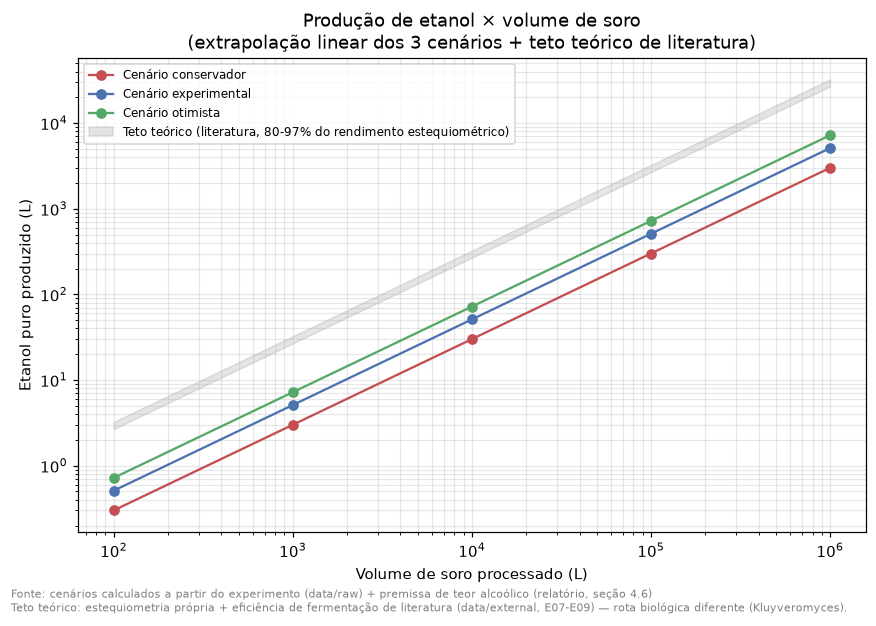

In [4]:
fig, ax = plt.subplots(figsize=(8, 5.5))

cores = {"conservador": "#c44e52", "experimental": "#4c72b0", "otimista": "#55a868"}
for cenario in m.SCENARIOS:
    sub = escala[escala["cenario"] == cenario]
    ax.plot(sub["soro_L"], sub["etanol_puro_L"], marker="o", label=f"Cenário {cenario}", color=cores[cenario])

# Teto teorico de literatura (banda min-max de eficiencia industrial)
eff_min, eff_max = m.LITERATURE_FERMENTATION_EFFICIENCY_RANGE
teto_min = [m.literature_ceiling_ethanol_g(v, eff_min) / (1000 * m.ETHANOL_DENSITY_G_PER_ML) for v in volumes_L]
teto_max = [m.literature_ceiling_ethanol_g(v, eff_max) / (1000 * m.ETHANOL_DENSITY_G_PER_ML) for v in volumes_L]
ax.fill_between(volumes_L, teto_min, teto_max, color="gray", alpha=0.2,
                 label="Teto teórico (literatura, 80-97% do rendimento estequiométrico)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Volume de soro processado (L)")
ax.set_ylabel("Etanol puro produzido (L)")
ax.set_title("Produção de etanol × volume de soro\n(extrapolação linear dos 3 cenários + teto teórico de literatura)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, which="both", alpha=0.3)
fig.text(0.01, -0.02,
         "Fonte: cenários calculados a partir do experimento (data/raw) + premissa de teor alcoólico (relatório, seção 4.6)\n"
         "Teto teórico: estequiometria própria + eficiência de fermentação de literatura (data/external, E07-E09) — rota biológica diferente (Kluyveromyces).",
         fontsize=7, color="gray")
plt.tight_layout()
plt.savefig("../assets/figures/fig_producao_vs_volume.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura do gráfico**: há uma distância grande (mais de uma ordem de grandeza) entre os três cenários baseados no nosso experimento e a faixa teórica de literatura. Isso é esperado — reforça que o resultado de bancada, mesmo qualitativamente positivo, está longe de um processo otimizado, e que **há espaço técnico real para melhoria** (motivo pelo qual a "continuidade do trabalho" citada na conclusão do relatório é relevante: densidade, controle de fermentação e ensaio de controle poderiam mudar bastante esse quadro).


## Gráfico 2 — Rendimento experimental × rendimento teórico × literatura

Comparação direta, em % do rendimento teórico estequiométrico, para a mesma base (250 mL de soro, escala do experimento).


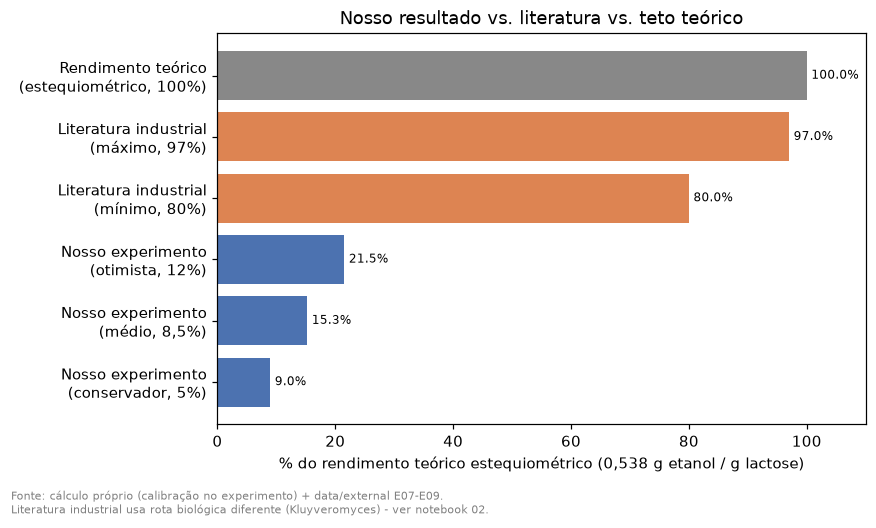

In [5]:
comparacao = pd.DataFrame({
    "referencia": [
        "Nosso experimento\n(conservador, 5%)",
        "Nosso experimento\n(médio, 8,5%)",
        "Nosso experimento\n(otimista, 12%)",
        "Literatura industrial\n(mínimo, 80%)",
        "Literatura industrial\n(máximo, 97%)",
        "Rendimento teórico\n(estequiométrico, 100%)",
    ],
    "percentual_do_teorico": [
        calibracao.loc[calibracao["cenario"] == "conservador", "eficiencia_sobre_teorico"].iloc[0] * 100,
        calibracao.loc[calibracao["cenario"] == "experimental", "eficiencia_sobre_teorico"].iloc[0] * 100,
        calibracao.loc[calibracao["cenario"] == "otimista", "eficiencia_sobre_teorico"].iloc[0] * 100,
        80, 97, 100,
    ],
    "tipo": ["Nosso experimento"]*3 + ["Literatura (rota diferente)"]*2 + ["Referência teórica"],
})

cor_tipo = {"Nosso experimento": "#4c72b0", "Literatura (rota diferente)": "#dd8452", "Referência teórica": "#888888"}
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(comparacao["referencia"], comparacao["percentual_do_teorico"],
                color=[cor_tipo[t] for t in comparacao["tipo"]])
ax.set_xlabel("% do rendimento teórico estequiométrico (0,538 g etanol / g lactose)")
ax.set_title("Nosso resultado vs. literatura vs. teto teórico")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
ax.set_xlim(0, 110)
fig.text(0.01, -0.05,
         "Fonte: cálculo próprio (calibração no experimento) + data/external E07-E09.\n"
         "Literatura industrial usa rota biológica diferente (Kluyveromyces) - ver notebook 02.",
         fontsize=7, color="gray")
plt.tight_layout()
plt.savefig("../assets/figures/fig_rendimento_comparacao.png", dpi=150, bbox_inches="tight")
plt.show()

## Principais perdas identificadas no processo

| Etapa | Perda observada | O que ela representa |
|---|---|---|
| Filtração (desproteinização) | 36% do volume (250→160 mL) | Soro retido no precipitado proteico + perdas de manipulação — inclui lactose que não chega a ser fermentada |
| Destilação | 90,6% do volume do mosto não vira destilado (160→15 mL) | Esperado fisicamente (a maior parte do mosto é água); não é uma "perda" no sentido de ineficiência, mas limita o volume final |
| Teor alcoólico desconhecido | Fator 2,4× entre cenário conservador e otimista | A maior fonte de incerteza do modelo técnico — resolvida apenas com a medição de densidade que não foi feita |
| Eficiência de conversão vs. teórico | Nosso melhor cenário usa ~22% do potencial químico da lactose disponível | Indica margem de melhoria: hidrólise incompleta, fermentação não otimizada, e/ou perda de lactose na filtração |

## Respostas às perguntas orientadoras

- **Quanto etanol obtivemos por litro de soro?** Entre 3,0 mL/L (conservador) e 7,2 mL/L (otimista) de etanol puro, dependendo do teor alcoólico assumido — não é um valor medido diretamente, é derivado da premissa de teor alcoólico.
- **Qual foi nosso rendimento frente ao teórico?** Entre ~9% e ~22% do rendimento estequiométrico máximo, conforme o cenário.
- **Como isso se compara à literatura?** Bem abaixo dos 80–97% reportados para fermentação industrial otimizada — mas usando uma rota biológica diferente (Kluyveromyces vs. lactase+*S. cerevisiae*), então a comparação é indicativa, não uma equivalência direta.
- **Quanto em 100 L / 1.000 L / ... / 1.000.000 L?** Ver tabela `escala_show` acima — variação linear dentro de cada cenário, com a ressalva de escala já discutida.
- **Principais perdas/limitações?** Ver tabela acima; a maior é a incerteza sobre o teor alcoólico, seguida da baixa eficiência de conversão frente ao teórico (esperada em processo não otimizado).

Seguimos para `04_economic_model`, que usa `escala` (este DataFrame) como base para custos e receita.
